In [263]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import sklearn
from sklearn.model_selection import train_test_split 
from sklearn import manifold
import seaborn as sns
from astropy.visualization import hist
import astropy
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from astroML.classification import GMMBayes

from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

from astroML.utils import split_samples, completeness_contamination

In [93]:
df_galaxy_quasar = pd.read_csv("galaxyquasar.csv")

In [95]:
df_galaxy_quasar

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [97]:
u = df_galaxy_quasar["u"]
g = df_galaxy_quasar["g"]
r = df_galaxy_quasar["r"]
i = df_galaxy_quasar["i"]
z = df_galaxy_quasar["z"]

$(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors

In [100]:
#they are working like dimesions 
UmG = u-g
GmR = g-r 
RmI = r-i 
Imz = i-z 

Text(0, 0.5, '$u-r$')

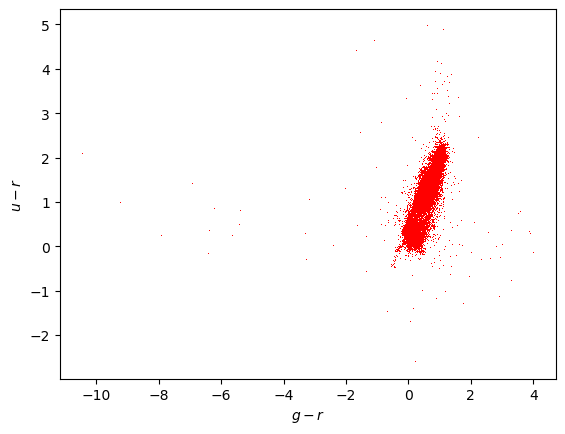

In [102]:
plt.plot(GmR, UmG, ",", color="red")
plt.xlabel(r"$g-r$")
plt.ylabel(r"$u-r$")

In [104]:
df_no_class = df_galaxy_quasar.drop(columns=['class'])

In [106]:
df_no_class

,u,g,r,i,z,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,2.011455,0.000631
...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,0.112571,0.000009


In [108]:
df_galaxy_quasar

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


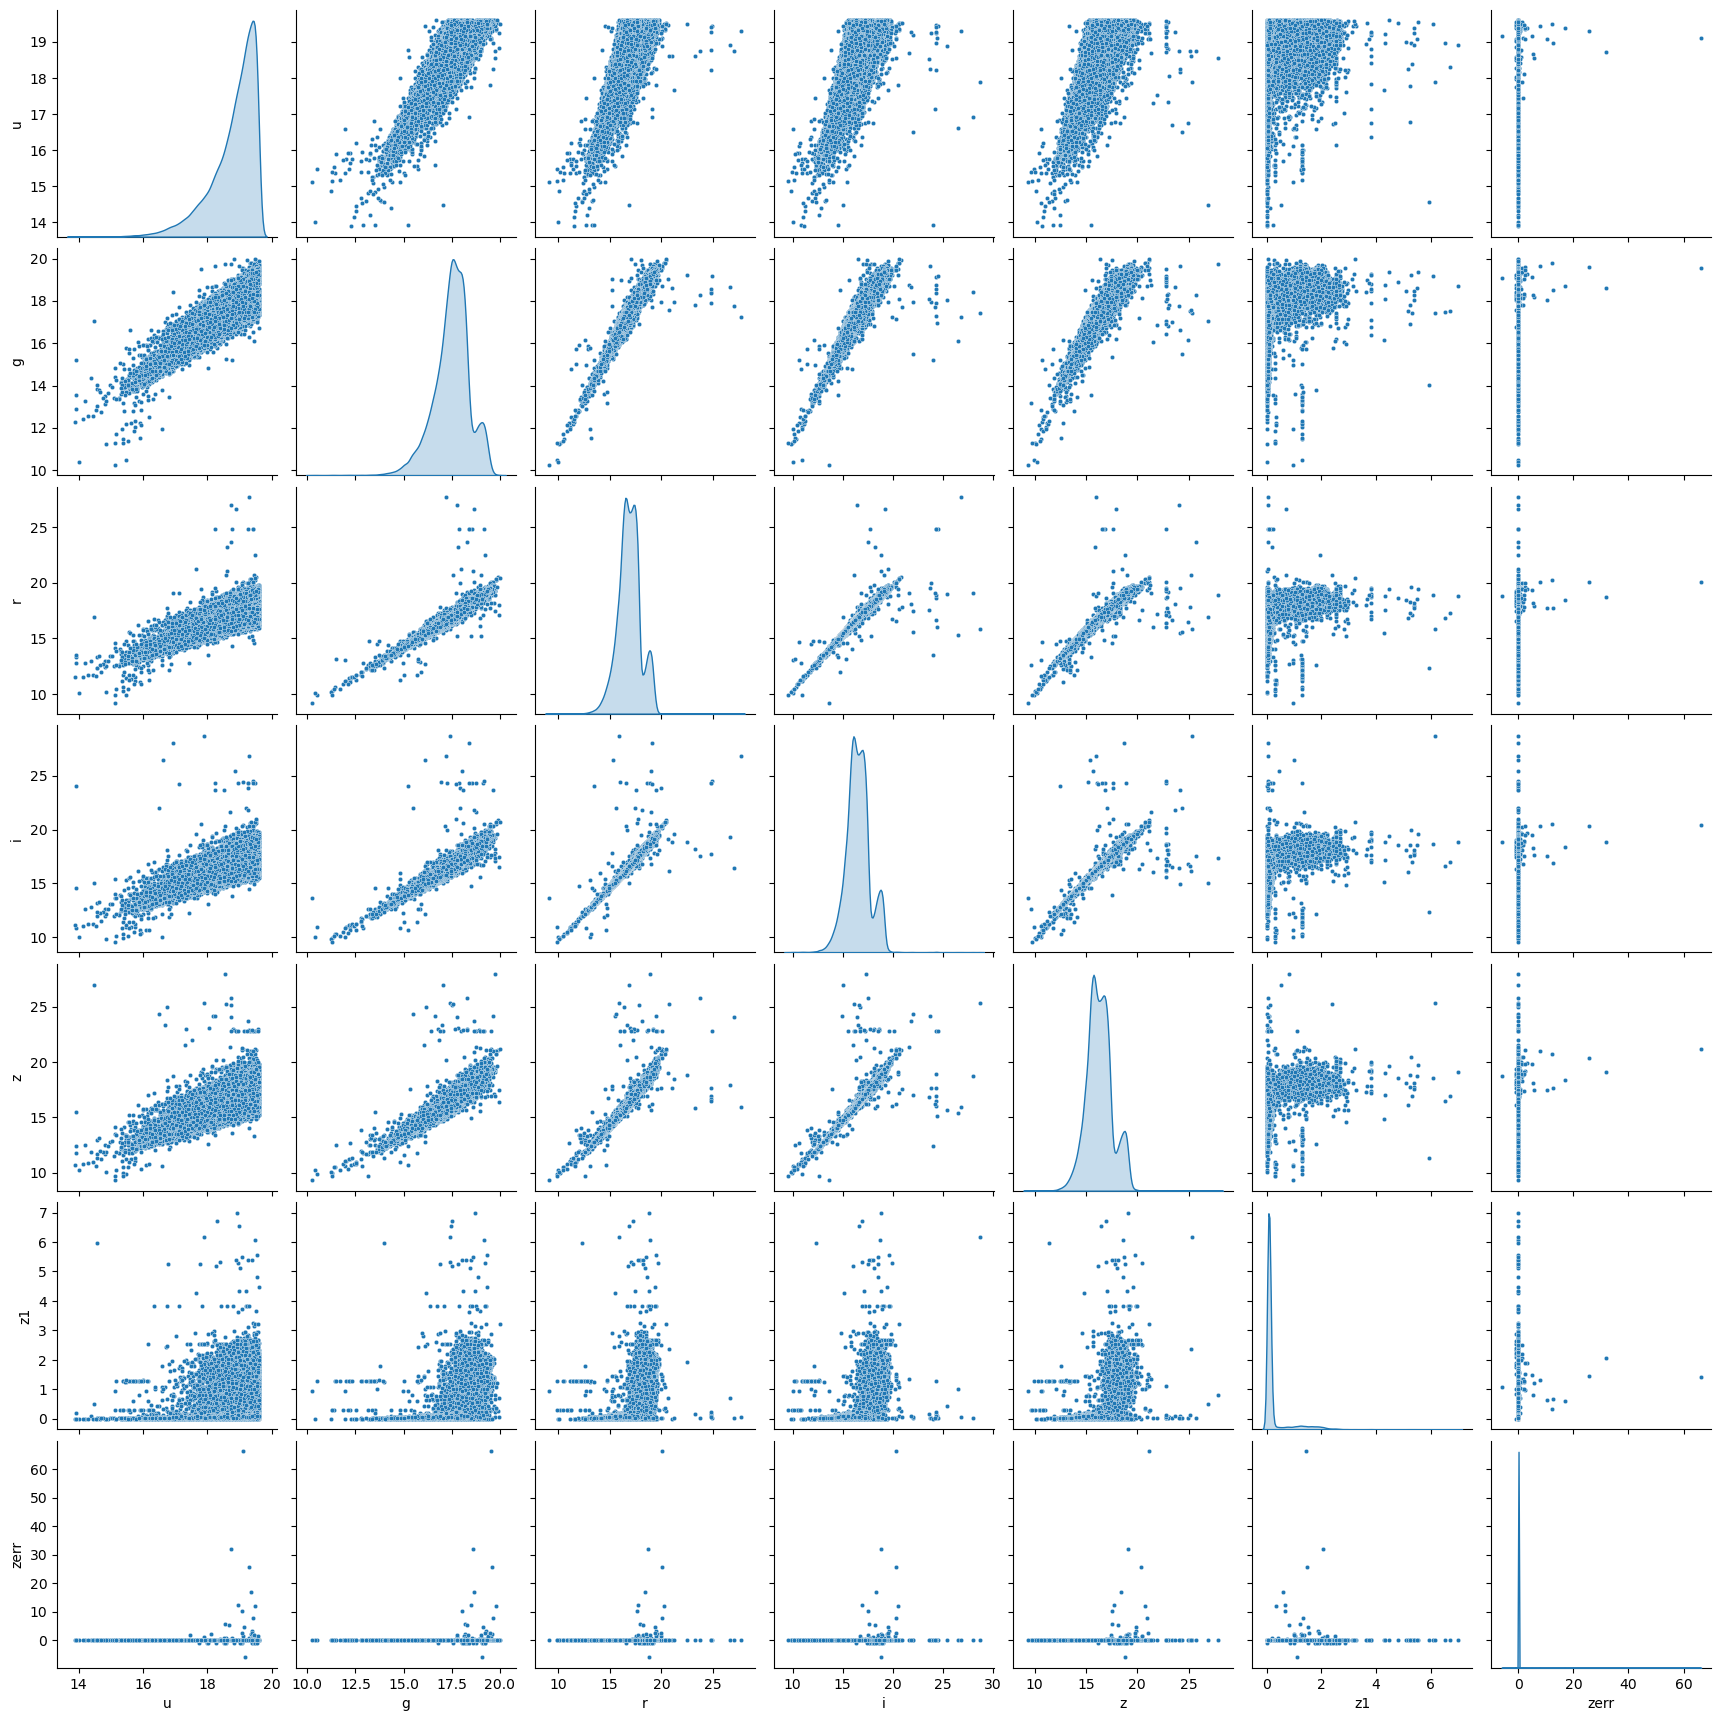

In [110]:
sns.pairplot(
    df_no_class,
    diag_kind="kde", 
    plot_kws={"s": 10, "alpha": 1}
)
plt.show()

Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.

In [112]:
CLASS = df_galaxy_quasar["class"]
print(CLASS)

0           QSO
1        GALAXY
2        GALAXY
3        GALAXY
4           QSO
          ...  
49995    GALAXY
49996    GALAXY
49997    GALAXY
49998    GALAXY
49999    GALAXY
Name: class, Length: 50000, dtype: object


In [113]:
class_labels = np.where(CLASS=='QSO',0,1) #zero is qso
print(class_labels)

[0 1 1 ... 1 1 1]


### this is done before test/spit and is only to analyze dataset

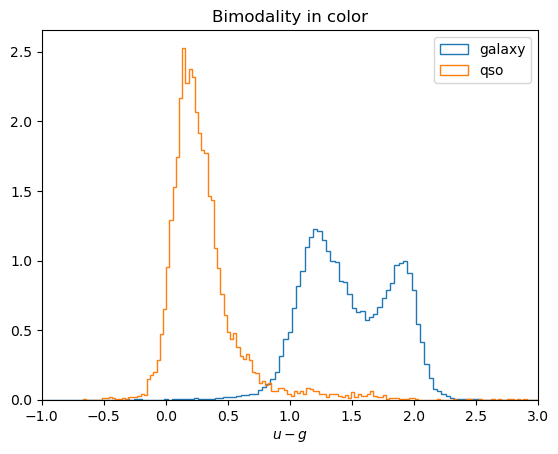

In [214]:
redshift = df_galaxy_quasar["z1"]
redshift_quasar = redshift[class_labels==0]
redshift_galaxy = redshift[class_labels==1]

UmG_galaxy = UmG[class_labels==1]
UmG_qso = UmG[class_labels==0]

astropy.visualization.hist(UmG_galaxy, bins="freedman", histtype="step",density=True, label="galaxy")
astropy.visualization.hist(UmG_qso, bins="freedman", histtype="step",density=True, label="qso")
plt.xlim(-1,3)
plt.xlabel(r"$u-g$")
plt.title("Bimodality in color")
plt.legend()

(-1.0, 3.0)

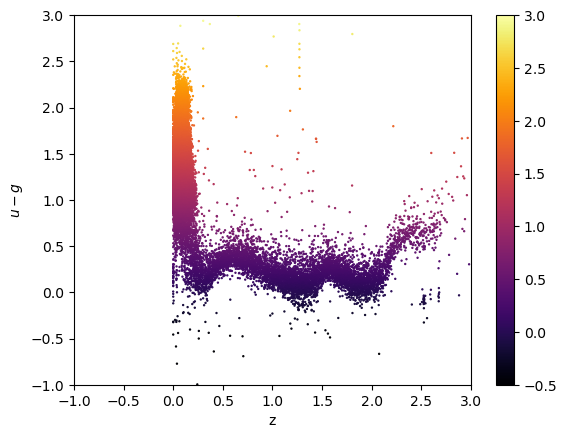

In [229]:
sc= plt.scatter(redshift, UmG, s=0.5, c=UmG, cmap="inferno")
plt.xlabel(r"z")
plt.ylabel(r"$ u-g $")
cbar = plt.colorbar(sc)
cbar.mappable.set_clim(vmin=-0.5, vmax=3)
plt.ylim(-1,3)
plt.xlim(-1,3)

In [169]:
df_color_only = df_galaxy_quasar.drop(columns=['class', 'z1', 'zerr'])
df_color_only

,u,g,r,i,z
0,18.97213,18.53676,18.58280,18.34936,18.29215
1,19.24592,17.47646,16.47817,16.04472,15.68851
2,19.43536,17.70268,16.91565,16.58327,16.39128
3,19.31626,18.18312,17.39591,16.94549,16.65395
4,19.28828,19.11188,18.88937,18.80013,18.49183
...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585
49996,18.52021,16.88262,16.03280,15.56884,15.22454
49997,18.62718,17.30876,16.87371,16.62399,16.42296
49998,19.55140,18.27711,17.62101,17.21947,17.03347


In [265]:
(X_train, X_test), (y_train, y_test) = split_samples(df_color_only, class_labels, [0.75, 0.25], random_state=0)


In [267]:
X_train.shape

(37500, 5)

In [269]:
# Fit all the models to the training data
def compute_models(*args):
    names = []
    probs = []
    for classifier, kwargs in args:
        print(classifier.__name__)
        clf = classifier(**kwargs)
        clf.fit(X_train, y_train)
        
        #Note that we are outputing the probabilities [of class 1], not the classes
        y_probs = clf.predict_proba(X_test)[:, 1]

        names.append(classifier.__name__)
        probs.append(y_probs)

    return names, probs


names, probs = compute_models((GaussianNB, {}),
                              (LinearDiscriminantAnalysis, {}),
                              (QuadraticDiscriminantAnalysis, {}),
                              (LogisticRegression,
                               dict(class_weight='balanced')),
                              (KNeighborsClassifier,
                               dict(n_neighbors=10)),
                              (DecisionTreeClassifier,
                               dict(random_state=0, max_depth=12,
                                    criterion='entropy')),
                              (GMMBayes, dict(n_components=3, tol=1E-5,
                                              covariance_type='full')))

GaussianNB
LinearDiscriminantAnalysis
QuadraticDiscriminantAnalysis
LogisticRegression
KNeighborsClassifier
DecisionTreeClassifier
GMMBayes


C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(ex

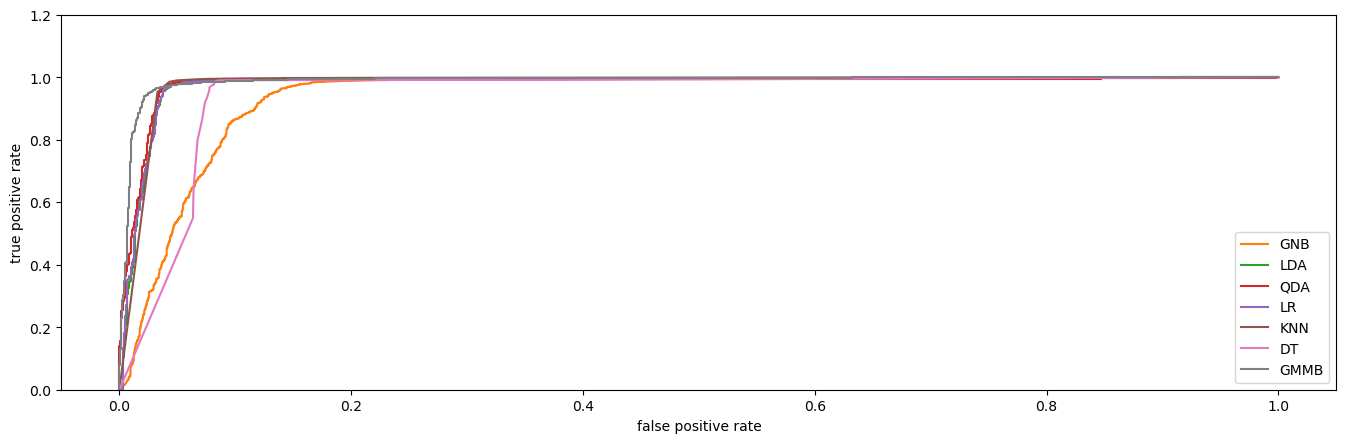

In [305]:
# Plot ROC curves 
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.9, wspace=0.25)
ax1 = plt.plot(131)
#define labels with dictionary
labels = dict(GaussianNB='GNB',
              LinearDiscriminantAnalysis='LDA',
              QuadraticDiscriminantAnalysis='QDA',
              KNeighborsClassifier='KNN',
              DecisionTreeClassifier='DT',
              GMMBayes='GMMB',
              LogisticRegression='LR')


for name, y_prob in zip(names, probs):
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    precision, recall, thresh2 = precision_recall_curve(y_test, y_prob)

    # add (0, 0) as first point
    fpr = np.concatenate([[0], fpr])
    tpr = np.concatenate([[0], tpr])
    plt.plot(fpr, tpr, label=labels[name])


plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.ylim(0,1.2)
plt.legend()

### try different classifier for different bands

In [340]:
print(y_train)
len(X_train[0])

[0 1 0 ... 1 1 1]


5

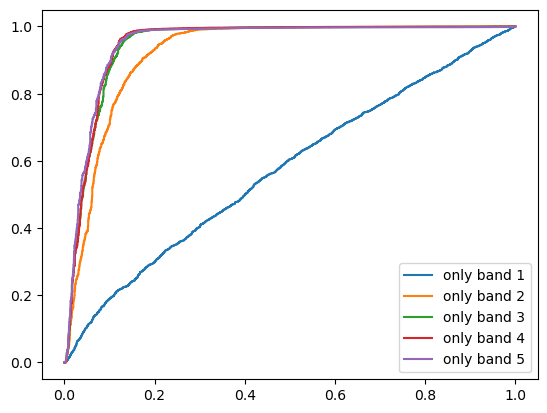

In [348]:
clf = GaussianNB()
#ho 5 bande
for i in range(5):

    clf.fit(X_train[:,i].reshape(-1,1) ,y_train)

    y_prob = clf.predict_proba(X_test[:,i].reshape(-1, 1)) [:,1] 
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"only band {i+1}")

plt.legend()

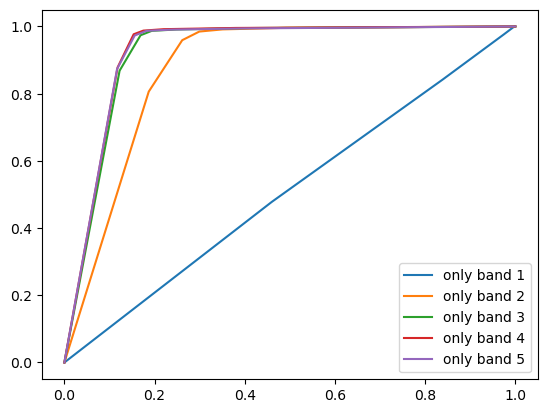

In [352]:
clf1 = KNeighborsClassifier()
#ho 5 bande
for i in range(5):

    clf1.fit(X_train[:,i].reshape(-1,1) ,y_train)

    y_prob = clf1.predict_proba(X_test[:,i].reshape(-1, 1)) [:,1] 
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"only band {i+1}")

plt.legend()

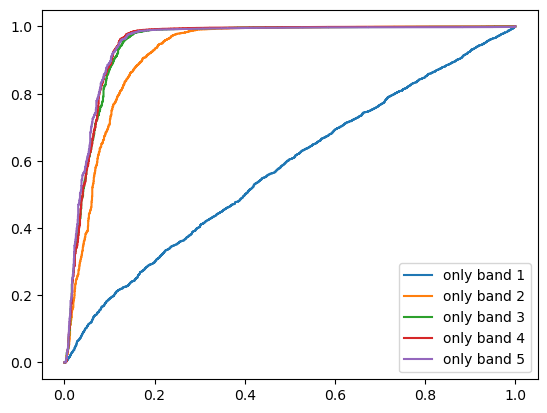

In [354]:
clf2 = LinearDiscriminantAnalysis()
#ho 5 bande
for i in range(5):

    clf2.fit(X_train[:,i].reshape(-1,1) ,y_train)

    y_prob = clf2.predict_proba(X_test[:,i].reshape(-1, 1)) [:,1] 
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"only band {i+1}")

plt.legend()

What are the colors that better satisty or invalidate the "Naive" assumption of indipendence between attributes?
only band 1 seem to be independent from all the other. The other four seems to converge and their behavior recall the one of the total ROC curve. 